- Learning with the MSELoss seems almost impossible
- KLDiv loss seems to help learning process though there are no results yet
- GAN does not care about loss and still does not work even though it seems to be learning

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [3]:
from src.load_sam_data import load_dataset

data_dir = "FJ"
dataset = load_dataset(data_dir)

..\data\FJ\FI01X1\FI01X1_ch


In [4]:
point_dim = len(dataset[0])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
dataset = scaler.fit_transform(dataset)
dataset = [scaler.fit_transform(h.reshape(-1, 1)).flatten() for h in dataset]

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [7]:
t = torch.rand(20)
x = nn.Linear(20, 40)(t)
print(F.relu(x))

tensor([0.4326, 0.0000, 0.0000, 0.1608, 0.0000, 0.3154, 0.3043, 0.4370, 0.1370,
        0.4210, 0.0000, 0.2984, 0.0000, 0.0000, 0.0000, 0.0227, 0.0000, 0.0000,
        0.3119, 0.3316, 0.0000, 0.0000, 0.0000, 0.1885, 0.0886, 0.4875, 0.0000,
        0.2887, 0.1321, 0.0000, 0.0000, 0.0000, 0.0000, 0.1080, 0.0000, 0.0000,
        0.1995, 0.1243, 0.0000, 0.8160], grad_fn=<ReluBackward0>)


In [8]:
pt = dataset[0]
pt = torch.tensor(pt).float()

pt = pt.reshape(1, 1, 96)

In [9]:
# DISCRIMINATOR testing

conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=4, stride=2)
conv2 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=4, stride=2)
conv3 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=4, stride=2)
torch.flatten(conv3(conv2(conv1(pt)))).shape

torch.Size([160])

In [10]:
# GENERATOR testing

tns = torch.tensor([np.random.random(1) for _ in range(20)]).float()
tns = tns.reshape(1,1,20)

conv1 = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2)
conv2 = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2)
conv1(conv2(tns)).shape

C:\Users\hrdyj\AppData\Local\Temp\ipykernel_42388\3269559132.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  tns = torch.tensor([np.random.random(1) for _ in range(20)]).float()


torch.Size([1, 1, 86])

In [110]:
# baseline on linear layers

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        #self.conv1 = nn.Conv1d(in_channels=1, out_channels=3, kernel_size=3, stride=2)
        #self.conv2 = nn.Conv1d(in_channels=3, out_channels=9, kernel_size=3, stride=2)
        #self.conv3 = nn.Conv1d(in_channels=9, out_channels=16, kernel_size=3, stride=2)
        #self.fc = nn.Linear()
        self.conv1 = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2)
        self.conv2 = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2)
        self.fc1 = nn.Linear(86, 90)
        self.fc2 = nn.Linear(90, 96)
        #self.fc1 = nn.Linear(20, 36)
        #self.fc2 = nn.Linear(36, 64)
        #self.fc3 = nn.Linear(64, 72)
        #self.fc4 = nn.Linear(72, 96)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.fc1(x))
        x = F.sigmoid(self.fc2(x))
        return x
    
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=4, stride=2)
        self.conv2 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=4, stride=2)
        self.conv3 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=4, stride=2)
        self.fc1 = nn.Linear(160, 64)
        self.fc2 = nn.Linear(64, 1)

        self.fc1 = nn.Linear(96, 80)
        self.fc2 = nn.Linear(80, 60)
        self.fc3 = nn.Linear(60, 40)
        self.fc4 = nn.Linear(40, 1)
    
    def forward(self, x):
        # first layer torch.Size([16, 4, 47])
        # second layer torch.Size([16, 8, 22])
        # third layer torch.Size([16, 16, 10])
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        #x = torch.flatten(x, start_dim=1)
        x = F.sigmoid(self.fc4(x))
        return x

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader

class HistogramDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        hist = self.data[idx]
        hist = torch.tensor(hist, dtype=torch.float32)
        return hist

ds = HistogramDataset(dataset)

dataloader = DataLoader(
    ds,
    batch_size=32,
    shuffle=False,
    num_workers=0 
)

In [140]:
gen = Generator()
disc = Discriminator()

lr = 0.0002
beta1 = 0.5
num_epochs = 200
latent_dim = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
criterion = nn.MSELoss()
criterion_2 = nn.MSELoss()
optimizer_G = torch.optim.Adam(gen.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = torch.optim.Adam(disc.parameters(), lr=lr, betas=(beta1, 0.999))

In [142]:
losses_D = []
losses_G = []

for epoch in range(num_epochs):
    for i, real_data in enumerate(dataloader):

        batch_size = real_data.size(0)
        
        real_labels = torch.ones(batch_size, 1, device=device) 
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # disc
        disc.zero_grad()
        real_data = real_data.reshape(batch_size, 1, point_dim)    
        
        # real data
        outputs_real = disc(real_data) # 16 x 96
        loss_real = criterion(outputs_real, real_labels)

        # generated data
        z = torch.randn(batch_size, 1, latent_dim, device=device)
        
        fake_data = gen(z) # output: 16 x 96
       
        outputs_fake = disc(fake_data.detach())
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward(retain_graph=True)
        optimizer_D.step()

        # gen
        gen.zero_grad()
        outputs = disc(fake_data)
        
        # gen tricking disc
        loss_G = criterion(outputs, real_labels)
        loss_G.backward()
        optimizer_G.step()
        
    losses_D.append(loss_D.detach().numpy())
    losses_G.append(loss_G.detach().numpy())

    if epoch % 20 == 0:
        print(f"Ep {epoch+1}/{num_epochs} Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

ValueError: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16, 1, 1])) is deprecated. Please ensure they have the same size.

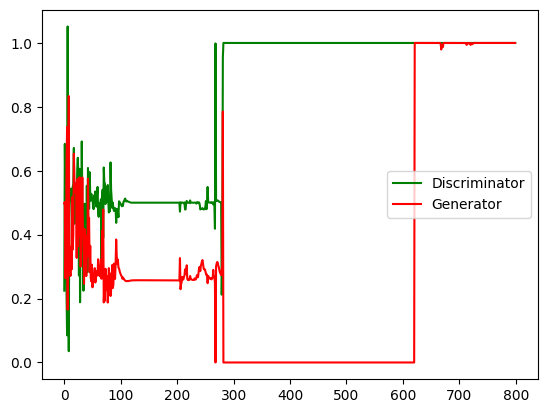

In [137]:
plt.plot(range(len(losses_D)), losses_D, color='green', label="Discriminator")
plt.plot(range(len(losses_G)), losses_G, color='red', label="Generator")
plt.legend()
plt.show()

In [138]:
scores = []

with torch.no_grad():
    for hist in dataloader:
        #hist = torch.tensor(hist, dtype=float)
        hist = hist.unsqueeze(1)
        score = 1 - disc(hist)
        for s in score:
            scores.append(s)       

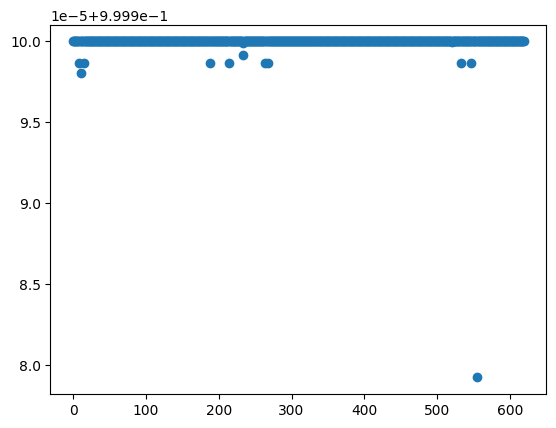

In [139]:
plt.scatter(range(len(scores)), scores)

In [118]:
outliers = np.where(np.array(scores) > 0.05)
outliers

(array([  8,  11,  15, 188, 214, 233, 234, 244, 263, 268, 344, 520, 533,
        546, 555]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

In [105]:
scores.index(max(scores))

344